# import Toolkit 

In [4]:


import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

print("Done")

Done


In [5]:
driver = "../assets/Flowers_Recognition/flowers"
folders =  os.listdir(driver)
labels = []
image_paths = []

for folder in folders:
    folder_path = os.path.join(driver, folder).replace("\\", "/")
    for image in os.listdir(folder_path):
        image_path = os.path.join(folder_path, image).replace("\\", "/")
        image_paths.append( image_path )
        labels.append(folder)


df = pd.DataFrame(
    {
        "images": image_paths,
        "labels": labels
    })
df.head()

,images,labels
0,../assets/Flowers_Recognition/flowers/daisy/10...,daisy
1,../assets/Flowers_Recognition/flowers/daisy/10...,daisy
2,../assets/Flowers_Recognition/flowers/daisy/10...,daisy
3,../assets/Flowers_Recognition/flowers/daisy/10...,daisy
4,../assets/Flowers_Recognition/flowers/daisy/10...,daisy


In [6]:
labels[:2] , image_paths[:2]

(['daisy', 'daisy'],
 ['../assets/Flowers_Recognition/flowers/daisy/100080576_f52e8ee070_n.jpg',
  '../assets/Flowers_Recognition/flowers/daisy/10140303196_b88d3d6cec.jpg'])

In [7]:
train , test = train_test_split(df, test_size=0.2, random_state=42, shuffle=True, stratify=df["labels"])
train, val = train_test_split(train, test_size=0.2, random_state=42, shuffle=True, stratify=train["labels"])

In [8]:
len(train) , len(test) , len(val)

(2762, 864, 691)

In [9]:
batch_size = 16
image_size = (224, 224)

tr_gen = ImageDataGenerator(
    rescale = 1./255,
    rotation_range = 20,
    zoom_range = 0.2,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    horizontal_flip = True,
    vertical_flip = True,
    shear_range = 0.2,
    fill_mode = "nearest"
)

tv_gen = ImageDataGenerator(
    rescale = 1./255   
)

tst_gen = ImageDataGenerator(
    rescale = 1./255
)

In [10]:
train_gen = tr_gen.flow_from_dataframe(
    val,
    x_col = "images",
    y_col = "labels",
    target_size = image_size,
    class_mode = "categorical",
    color_mode = "rgb",
    shuffle = True,
    batch_size = batch_size
)   

val_gen = tv_gen.flow_from_dataframe(
    train,
    x_col = "images",
    y_col = "labels",
    target_size = image_size,
    class_mode = "categorical",
    color_mode = "rgb",
    shuffle = True,
    batch_size = batch_size
)  

test_gen = tst_gen.flow_from_dataframe(
    test,
    x_col = "images",
    y_col = "labels",
    target_size = image_size,
    class_mode = "categorical",
    color_mode = "rgb",
    shuffle = True,
    batch_size = batch_size
)  

Found 691 validated image filenames belonging to 5 classes.
Found 2762 validated image filenames belonging to 5 classes.
Found 864 validated image filenames belonging to 5 classes.


In [11]:
gen_dict = train_gen.class_indices
classes = list(gen_dict.keys())
classes

['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']

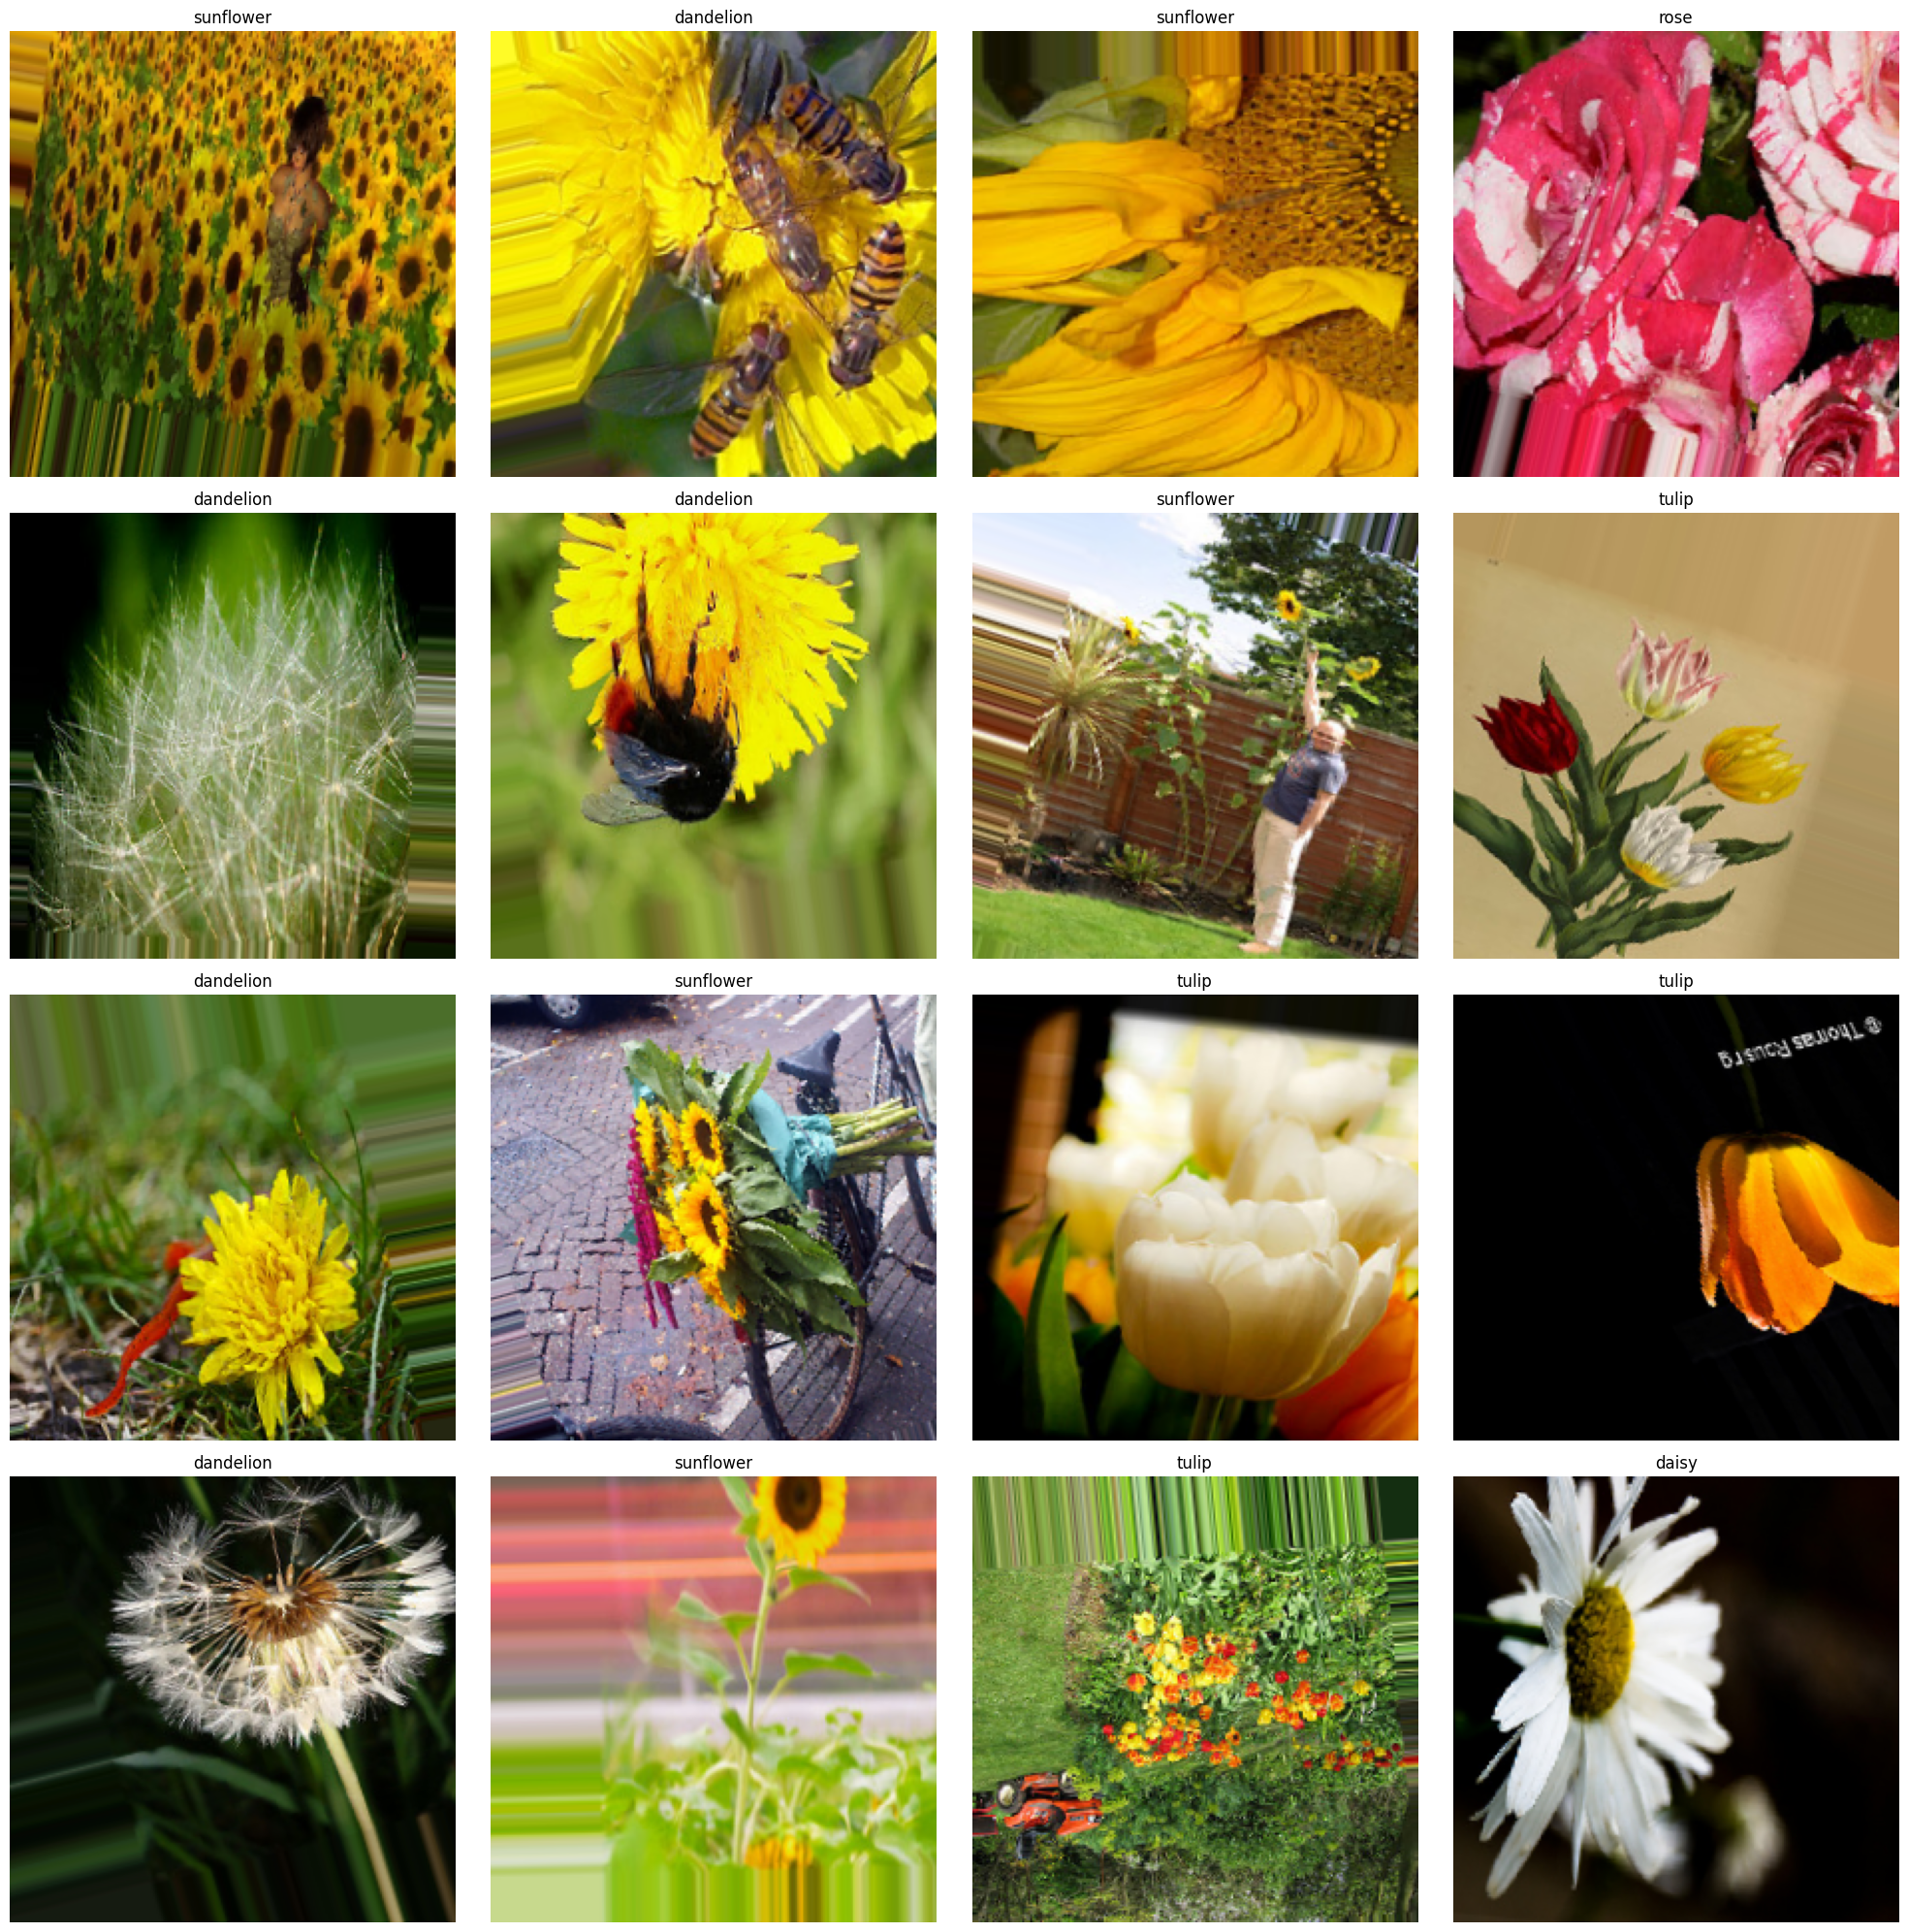

In [12]:
image , label = next(train_gen)
plt.figure(figsize=(20, 25))

for i in range(16):
    plt.subplot(5, 4, i+1)
    plt.imshow(image[i])
    plt.title(classes[np.argmax(label[i])])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
def conv_block(filters, reg):
    return [
        layers.Conv2D(
            filters,
            (3, 3),
            padding="same",
            activation="relu",
            kernel_regularizer=reg,
            bias_regularizer=reg
        ),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.2)
    ]

In [14]:
image_shape = (image_size[0], image_size[1], 3)
reg = keras.regularizers.l2(1e-4)

model = keras.Sequential([
    keras.Input(shape=image_shape),

    *conv_block(32, reg),
    *conv_block(64, reg),
    *conv_block(128, reg),
    *conv_block(256, reg),

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(
        64,
        activation="relu",
        kernel_regularizer=reg,
        bias_regularizer=reg
    ),
    layers.BatchNormalization(),
    layers.Dropout(0.3),

    layers.Dense(5, activation="softmax")
])

I0000 00:00:1776373683.448388   42783 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5527 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Ti, pci bus id: 0000:05:00.0, compute capability: 8.9


In [15]:
model.compile(
    optimizer = keras.optimizers.Adamax(),
    loss = keras.losses.CategoricalCrossentropy(),
    metrics = ["accuracy"]
)

In [21]:
history = model.fit(
    train_gen,
    validation_data = val_gen,
    epochs = 30,
    verbose = 1,
    
)

Epoch 1/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 536ms/step - accuracy: 0.4790 - loss: 1.4516 - val_accuracy: 0.2650 - val_loss: 2.1620
Epoch 2/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 589ms/step - accuracy: 0.4718 - loss: 1.4259 - val_accuracy: 0.2878 - val_loss: 2.0442
Epoch 3/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 598ms/step - accuracy: 0.4949 - loss: 1.3733 - val_accuracy: 0.3049 - val_loss: 2.1502
Epoch 4/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 24s 544ms/step - accuracy: 0.4848 - loss: 1.3787 - val_accuracy: 0.3327 - val_loss: 2.0352
Epoch 5/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 599ms/step - accuracy: 0.4964 - loss: 1.3753 - val_accuracy: 0.3860 - val_loss: 1.7619
Epoch 6/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 590ms/step - accuracy: 0.5195 - loss: 1.3463 - val_accuracy: 0.3946 - val_loss: 1.8732
Epoch 7/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 26s 588ms/step - accuracy: 0.4747 - loss: 1.3988 - val_accuracy: 0.4175 - val_loss: 1.7745
Epoch 8/30
44/44 ━━━━━━━━━━━━━━━━━━━━ 23s 524ms/step - accuracy: 0.5051 - loss: 1.3500 - val_accu

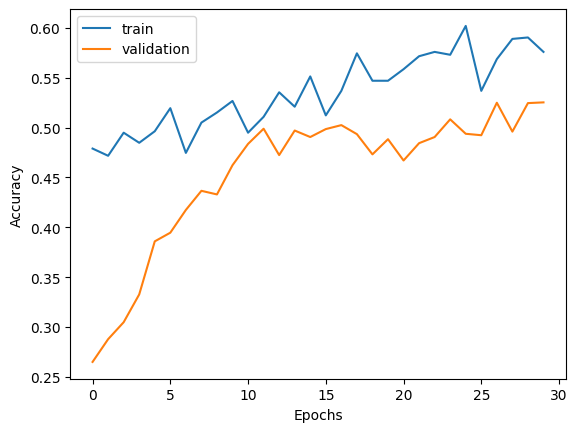

In [22]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="validation")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()